In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer,IterativeImputer,KNNImputer
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder,TargetEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler,PowerTransformer

from sklearn.compose import ColumnTransformer   
from sklearn.pipeline import Pipeline

import pickle
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [3]:
df=pd.read_csv("heart.csv")

In [4]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [5]:
df.describe(include="all")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [6]:
df["HeartDisease"].value_counts(normalize=True) 

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


-0.19593302867569365


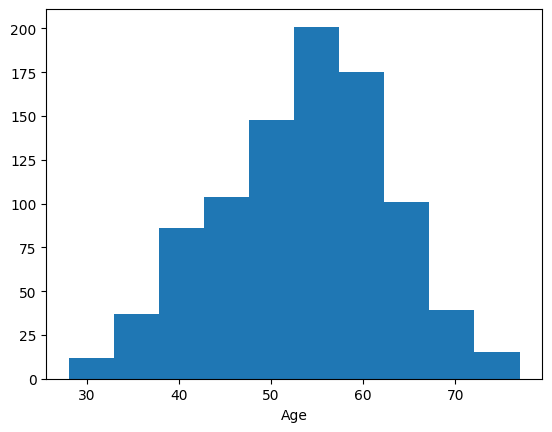

0.1798393100516288


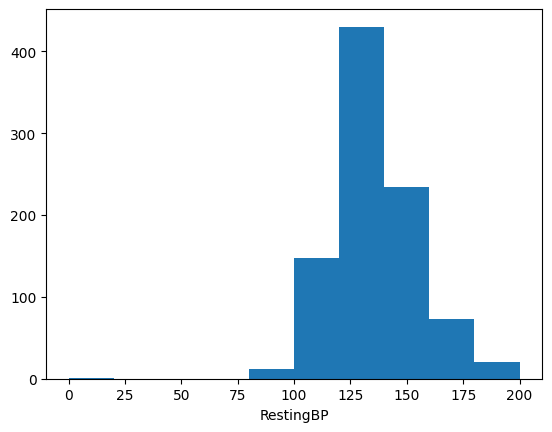

-0.6100864307268192


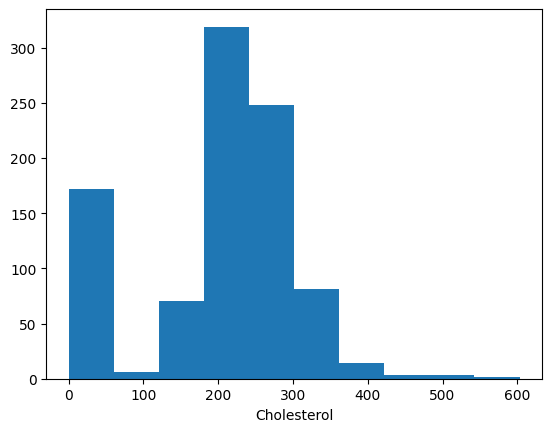

1.2644841750727027


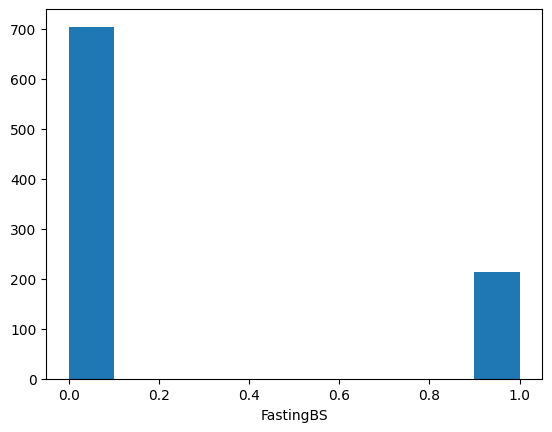

-0.14435941846180994


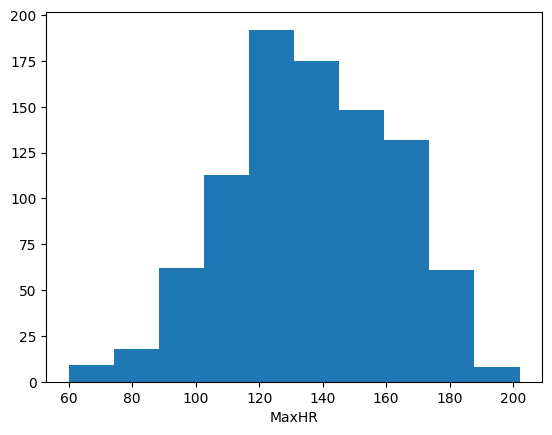

1.0228720218107528


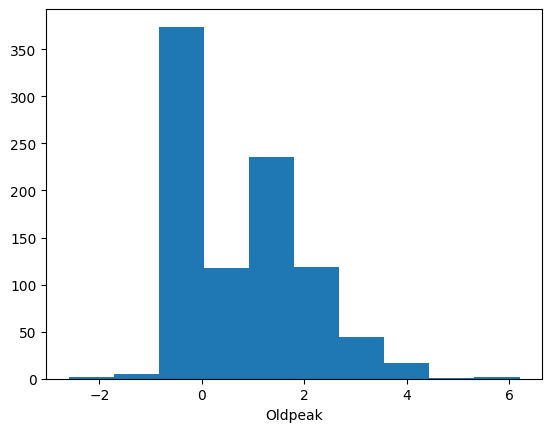

-0.21508633825088655


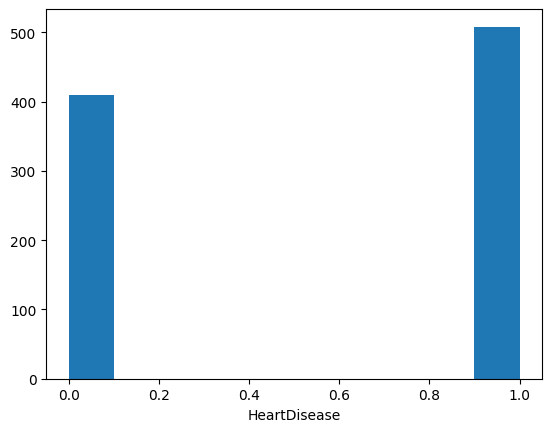

In [8]:
columns=df.select_dtypes(include="number")
for col in columns:
    print(df[col].skew())
    plt.Figure()
    plt.hist(df[col])
    plt.xlabel(col)
    plt.show()

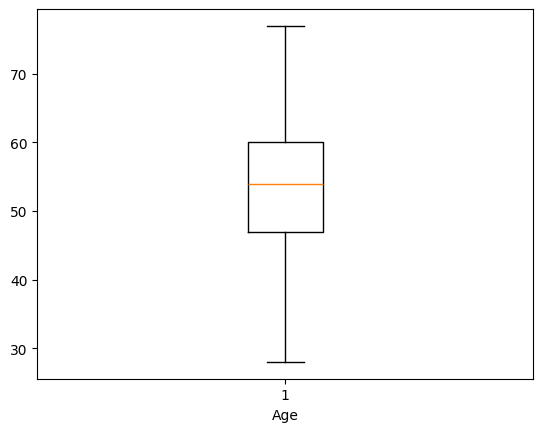

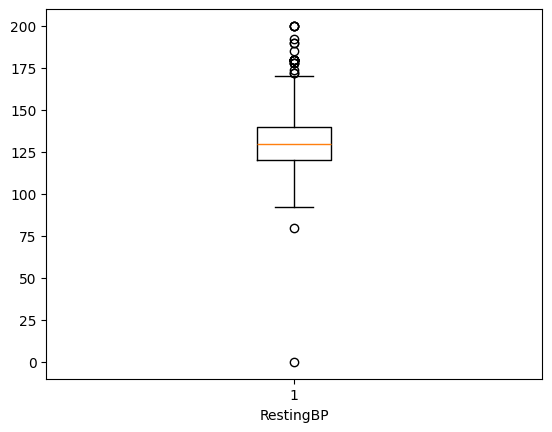

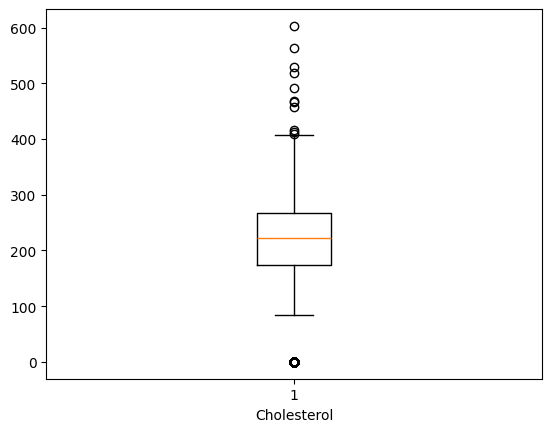

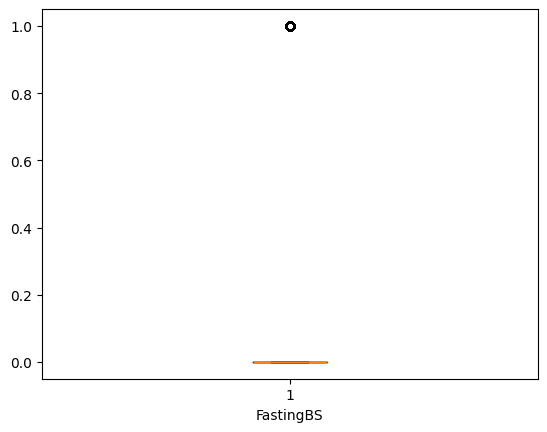

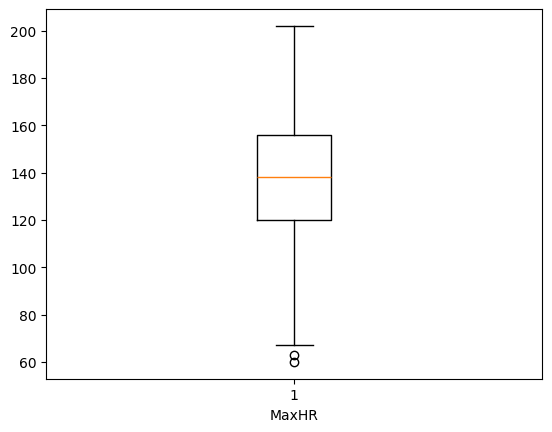

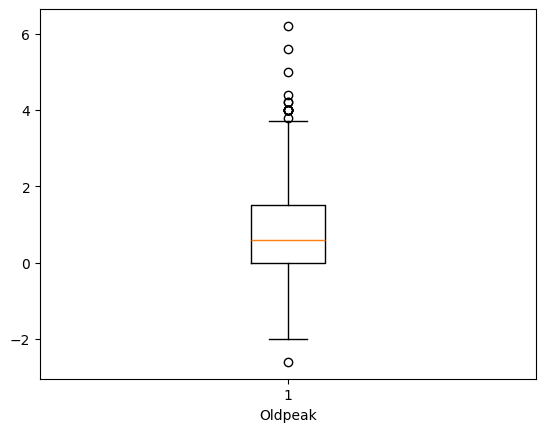

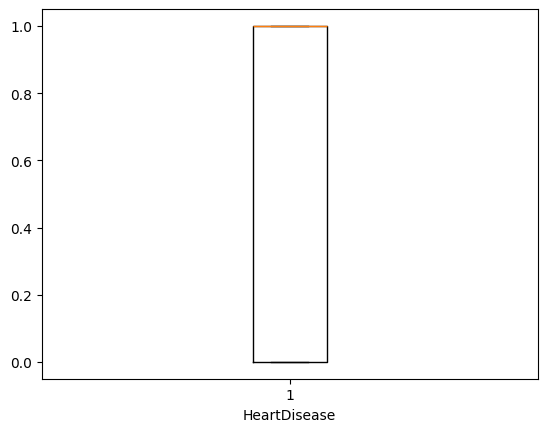

In [9]:
for col in columns:
    plt.Figure()
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

# splitting

In [10]:
x=df.drop(["HeartDisease"],axis=1)
y=df["HeartDisease"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True,stratify=y)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [12]:
#=============columns=============
#sex,ChestPainType,RestingECG,ST_Slope-->one
#ExerciseAngina-->ordinal


Ohe_cols=["Sex","ChestPainType","RestingECG","ST_Slope"]
ordinal_cols=["ExerciseAngina"]
StandardScale_cols=["Age","RestingBP","Cholesterol","MaxHR"]
yeo_cols=["Oldpeak"]


In [13]:
ohe_pipeline = Pipeline([
    ("ohe_cols", OneHotEncoder())
])

standard_scale_pipeline = Pipeline([
    ("standard_scale_cols", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("ordinal_cols", OrdinalEncoder())
])

yeo_pipeline = Pipeline([
    ("yeo_cols", PowerTransformer(method="yeo-johnson"))
])

In [14]:
#=============column_transform=======
transform=ColumnTransformer([
    ("ohe_pipline",ohe_pipeline,["Sex","ChestPainType","RestingECG","ST_Slope"]),
    ("StandardScale_pipline",standard_scale_pipeline,["Age","RestingBP","Cholesterol","MaxHR"]),
    ("ordinal_pipline",ordinal_pipeline,["ExerciseAngina"]),
    ("yeo_pipline",yeo_pipeline,["Oldpeak"])
]
,remainder="passthrough"
)

In [15]:
x_train_transformed=transform.fit_transform(x_train)
x_test_transformed=transform.transform(x_test)

In [16]:
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.experimental import enable_hist_gradient_boosting #for Histgrad
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier,ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier,HistGradientBoostingClassifier
from sklearn.ensemble import  StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,balanced_accuracy_score#confusion_matrix,classification_report,RocCurveDisplay,roc_auc_score

In [17]:
models={
    "lg":LogisticRegression(),
    "naive":GaussianNB(),
    "KNN":KNeighborsClassifier(),
    # "SVM":SVC(),
    "DTree":DecisionTreeClassifier(),
    "Random forest":RandomForestClassifier(),
    "Extra":ExtraTreesClassifier(),
    "bagging":BaggingClassifier(),
    "Adaboost":AdaBoostClassifier(),
    "Gboost":GradientBoostingClassifier(),
    "HGboost":HistGradientBoostingClassifier(),
    "stacking":StackingClassifier(
    estimators=[
        (
            "lr",
            LogisticRegression(
                max_iter=1000
            )
        ),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=5,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ],
    final_estimator=LogisticRegression(
        max_iter=1000
    )
),
    "Xgboosing":XGBClassifier(),
    "Catboosing":CatBoostClassifier(),
    "LGBM":LGBMClassifier()

}

metrics={
    "acc":accuracy_score,
    "precision":precision_score,
    "recall":recall_score,
    "balance_acc":balanced_accuracy_score,
    "f1_score":f1_score
    
}


In [18]:
results = {}

for name, model in models.items():

    model.fit(x_train_transformed, y_train)

    y_pred = model.predict(x_test_transformed)
    #note
 

    results[name] = {
        "accuracy_score": accuracy_score(y_test, y_pred),
        "precision_score": precision_score(y_test, y_pred),
        "recall_score": recall_score(y_test, y_pred),
        "balanced_accuracy_score": balanced_accuracy_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
    }

    print(name, "done")

lg done
naive done
KNN done
DTree done
Random forest done
Extra done
bagging done
Adaboost done
Gboost done
HGboost done
stacking done
Xgboosing done
Learning rate set to 0.009028
0:	learn: 0.6835188	total: 153ms	remaining: 2m 33s
1:	learn: 0.6749836	total: 159ms	remaining: 1m 19s
2:	learn: 0.6669191	total: 163ms	remaining: 54.2s
3:	learn: 0.6593049	total: 167ms	remaining: 41.7s
4:	learn: 0.6513190	total: 175ms	remaining: 34.8s
5:	learn: 0.6445757	total: 179ms	remaining: 29.7s
6:	learn: 0.6374812	total: 183ms	remaining: 26s
7:	learn: 0.6306653	total: 188ms	remaining: 23.3s
8:	learn: 0.6232396	total: 192ms	remaining: 21.1s
9:	learn: 0.6158578	total: 196ms	remaining: 19.4s
10:	learn: 0.6087044	total: 201ms	remaining: 18s
11:	learn: 0.6022311	total: 205ms	remaining: 16.9s
12:	learn: 0.5958550	total: 209ms	remaining: 15.9s
13:	learn: 0.5901407	total: 214ms	remaining: 15.1s
14:	learn: 0.5839928	total: 225ms	remaining: 14.8s
15:	learn: 0.5781128	total: 230ms	remaining: 14.1s
16:	learn: 0.573

In [19]:

results_df = pd.DataFrame(results).T

print(results_df.sort_values("f1_score", ascending=False))

               accuracy_score  precision_score  recall_score  \
Extra                0.913043         0.898148      0.950980   
stacking             0.902174         0.888889      0.941176   
Random forest        0.902174         0.896226      0.931373   
KNN                  0.896739         0.895238      0.921569   
Catboosing           0.896739         0.902913      0.911765   
Gboost               0.891304         0.901961      0.901961   
lg                   0.885870         0.871560      0.931373   
Adaboost             0.885870         0.900990      0.892157   
naive                0.880435         0.884615      0.901961   
HGboost              0.880435         0.908163      0.872549   
Xgboosing            0.869565         0.882353      0.882353   
LGBM                 0.869565         0.890000      0.872549   
bagging              0.842391         0.884211      0.823529   
DTree                0.788043         0.805825      0.813725   

               balanced_accuracy_score 

In [20]:
best_model_name = results_df["f1_score"].idxmax()

print("Best Model:", best_model_name)
print("F1 Score:", results_df.loc[best_model_name, "f1_score"])
print("Balanced Accuracy:", results_df.loc[best_model_name, "balanced_accuracy_score"])

Best Model: Extra
F1 Score: 0.9238095238095239
Balanced Accuracy: 0.9084170253467241


Best Model: Extra


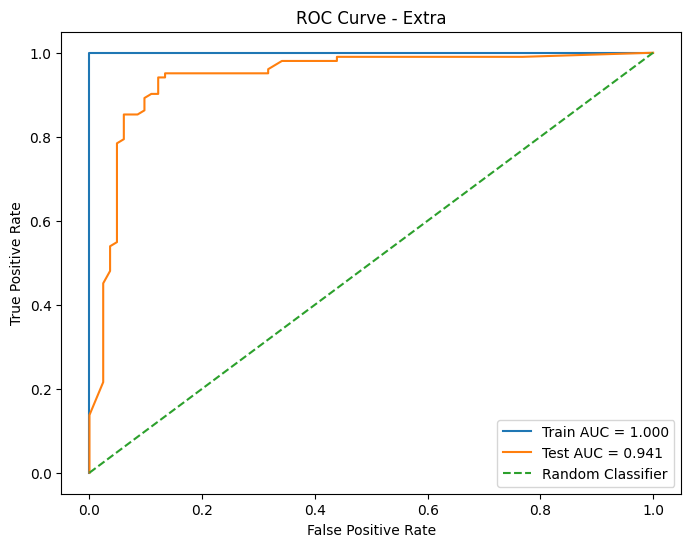

Train ROC-AUC: 1.0
Test ROC-AUC: 0.9408177905308465
AUC Gap: 0.059182209469153535


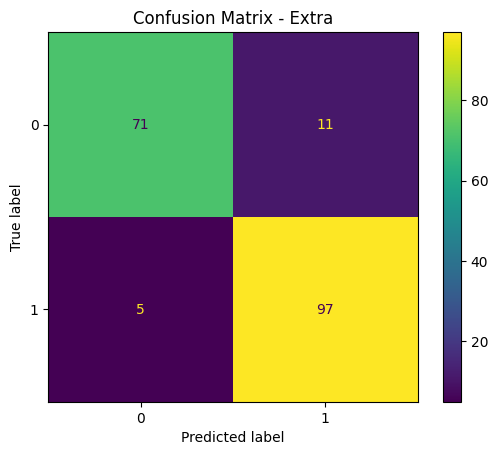


Train vs Test Performance:
                   Train      Test       Gap
Accuracy             1.0  0.913043  0.086957
Precision            1.0  0.898148  0.101852
Recall               1.0  0.950980  0.049020
F1 Score             1.0  0.923810  0.076190
Balanced Accuracy    1.0  0.908417  0.091583


In [21]:


from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)


# ==============================
# Get Best Model
# ==============================

best_model_name = results_df["f1_score"].idxmax()
best_model = models[best_model_name]

print("Best Model:", best_model_name)


# ==============================
# Predictions
# ==============================

y_train_pred = best_model.predict(x_train_transformed)
y_test_pred = best_model.predict(x_test_transformed)

y_train_proba = best_model.predict_proba(x_train_transformed)[:, 1]
y_test_proba = best_model.predict_proba(x_test_transformed)[:, 1]


# ==============================
# ROC - Train vs Test
# ==============================

fpr_train, tpr_train, _ = roc_curve(
    y_train,
    y_train_proba
)

fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_test_proba
)

auc_train = roc_auc_score(
    y_train,
    y_train_proba
)

auc_test = roc_auc_score(
    y_test,
    y_test_proba
)


plt.figure(figsize=(8, 6))

plt.plot(
    fpr_train,
    tpr_train,
    label=f"Train AUC = {auc_train:.3f}"
)

plt.plot(
    fpr_test,
    tpr_test,
    label=f"Test AUC = {auc_test:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.show()


print("Train ROC-AUC:", auc_train)
print("Test ROC-AUC:", auc_test)
print("AUC Gap:", auc_train - auc_test)


# ==============================
# Confusion Matrix
# ==============================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


# ==============================
# Train vs Test Metrics
# ==============================

comparison = pd.DataFrame({
    "Train": [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        balanced_accuracy_score(y_train, y_train_pred)
    ],

    "Test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        balanced_accuracy_score(y_test, y_test_pred)
    ]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Balanced Accuracy"
])


comparison["Gap"] = comparison["Train"] - comparison["Test"]

print("\nTrain vs Test Performance:")
print(comparison)

In [22]:
from sklearn.pipeline import Pipeline
import joblib

final_model = Pipeline([
    ("preprocessor", transform),
    ("model", models["stacking"])
])

final_model.fit(x_train, y_train)

joblib.dump(final_model, "heart_disease_model.pkl")

['heart_disease_model.pkl']

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

cv_pipeline = Pipeline([
    ("preprocessor", transform),
    ("model", models["stacking"])
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    cv_pipeline,
    x_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "balanced_accuracy": "balanced_accuracy"
    }
)

print("CV Accuracy:", cv_results["test_accuracy"].mean())
print("CV Precision:", cv_results["test_precision"].mean())
print("CV Recall:", cv_results["test_recall"].mean())
print("CV F1:", cv_results["test_f1"].mean())
print("CV ROC-AUC:", cv_results["test_roc_auc"].mean())
print("CV Balanced Accuracy:",
      cv_results["test_balanced_accuracy"].mean())

CV Accuracy: 0.8624359332774205
CV Precision: 0.8615784539036163
CV Recall: 0.8990665462210178
CV F1: 0.8792653756434877
CV ROC-AUC: 0.9325527809538651
CV Balanced Accuracy: 0.8581113616885974


In [24]:
# ==============================
# Imports
# ==============================

import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline


# ==============================
# Models to Compare
# ==============================

models_to_compare = {
    "GradientBoosting": GradientBoostingClassifier(random_state=42),

    "HistGradient": HistGradientBoostingClassifier(random_state=42),

    "Extra": ExtraTreesClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "AdaBoosting": AdaBoostClassifier(random_state=42),

    "Bagging": BaggingClassifier(random_state=42),

    "LG": LogisticRegression(max_iter=1000),

    "Naive": GaussianNB(),

    "D Tree": DecisionTreeClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "Stacking": StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000)),
            ("rf", RandomForestClassifier(random_state=42))
        ],
        final_estimator=LogisticRegression(max_iter=1000)
    )
}


# ==============================
# Cross Validation
# ==============================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


cv_results = []


for name, model in models_to_compare.items():

    pipeline = Pipeline([
        ("preprocessor", transform),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        x_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc",
            "balanced_accuracy": "balanced_accuracy"
        }
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "Balanced Accuracy": scores["test_balanced_accuracy"].mean()
    })


cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    "F1",
    ascending=False
)

print(cv_results_df)

               Model  Accuracy  Precision    Recall        F1   ROC-AUC  \
10          Stacking  0.862436   0.858679  0.903975  0.879874  0.930081   
1       HistGradient  0.862417   0.859879  0.899036  0.878801  0.925265   
3      Random Forest  0.858336   0.853109  0.903975  0.876548  0.928754   
9                KNN  0.854235   0.851896  0.894068  0.872047  0.904799   
6                 LG  0.851533   0.858277  0.879404  0.868227  0.924003   
0   GradientBoosting  0.854282   0.870722  0.867058  0.867911  0.923146   
4        AdaBoosting  0.851524   0.862073  0.874466  0.867669  0.922569   
2              Extra  0.840602   0.851539  0.867058  0.857573  0.915768   
7              Naive  0.836548   0.858745  0.847305  0.851998  0.913949   
5            Bagging  0.822878   0.843573  0.837549  0.839532  0.902948   
8             D Tree  0.802432   0.829576  0.815357  0.821132  0.801082   

    Balanced Accuracy  
10           0.857512  
1            0.858096  
3            0.852943  
9  